# Computer Exercise 15.12 — Problem 2
## Implicit Quantile Networks (IQN, tabular with cosine τ-embedding)

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.12
> **날짜**: 2026-07-27
> **언어**: 한국어 본문 + 영문 라벨

## 1. 문제 (원문)

> **Implicit Quantile Networks (IQN).** QR-DQN parameterises the return distribution at $K$ *fixed* quantile locations $\{\theta_k(s,a)\}$; the number and placement of these anchors is a modelling choice. Dabney et al. (2018b) propose an implicit parameterisation: represent the full quantile function $F^{-1}(\tau \mid s, a)$ by a function $Z_\psi(s, a; \tau)$ that *takes $\tau$ as input*, sampling fresh $\tau \sim \mathcal U(0, 1)$ at every step. In the neural-network setting this is $\phi(\tau) \odot h(s)$ where $\phi(\tau)_i = \cos(i\pi\tau)$ is a cosine embedding. In tabular form the equivalent is a per-$(s,a)$ linear head $w(s, a) \in \mathbb R^D$ with $F^{-1}(\tau \mid s, a) = \phi(\tau)^\top w(s, a) + b(s, a)$. Show, on the same stochastic-reward GridWorld, that (i) the sampled-$\tau$ regime learns as well as QR-DQN with far fewer stored parameters per state ($D+1$ vs $K$), (ii) evaluating the learned $F^{-1}$ at arbitrary $\tau$ (e.g., CVaR at $\tau=0.1$) is straightforward, and (iii) sample efficiency and mean accuracy match QR-DQN despite the stochastic quantile sampling.

### 한국어 풀이용 정리

- 환경: Day 79 Problem 1 과 동일한 4×4 GridWorld + 잡음 보상.
- 파라미터화: 각 $(s, a)$ 에 대해 $F^{-1}(\tau \mid s, a) = \phi(\tau)^\top w(s, a) + b(s, a)$, $\phi(\tau)_i = \cos(i\pi\tau)$, $i = 1,\dots,D$. Tabular 인덱스는 $(s, a)$, "네트워크" 는 τ 에 대한 선형 사상.
- 학습: 매 스텝 $M_\text{on} = 8$ 온라인 τ, $M_\text{tar} = 8$ target τ 샘플 → quantile Huber loss.
- 비교: **scalar Q** / **QR-DQN (K=31)** / **IQN (D=16, sampled τ)** — 3 방법 tail-50 리턴, mean-Q 오차, 학습된 quantile 함수.
- 목적: 지지대 이산화도 없고, quantile 개수 선택 부담도 없는 "완전 분포" 학습이 tabular 규모에서도 등가 성능을 내는지.

## 2. 수학적 배경

**Cosine τ-embedding.** $\phi(\tau) \in \mathbb R^D$ with $\phi(\tau)_i = \cos(i\pi\tau)$, $i=1,\dots,D$. 이 basis 는 $L^2[0,1]$ 에서 완비이며 (Fourier), IQN 은 이를 통해 quantile 함수를 임의 정밀도로 근사한다.

**Tabular-IQN parametrisation.**
$$Z_\psi(s, a; \tau) = \phi(\tau)^\top w(s, a) + b(s, a), \qquad w(s,a) \in \mathbb R^D, \ b(s,a) \in \mathbb R.$$
평균은 $\phi$ 의 tau-적분이 0 이 되도록:
$$\mathbb E_\tau[Z] = b(s, a) + \sum_{i=1}^D w_i(s, a) \int_0^1 \cos(i\pi\tau)\,d\tau = b(s, a),$$
왜냐하면 $\int_0^1 \cos(i\pi\tau) d\tau = 0$ for $i \ge 1$. 즉 $b(s, a) = Q(s, a)$ 로 해석 가능하고 $w(s,a)$ 는 분포 형태만 담당.

**IQN target with sampled τ.** 매 스텝 $M_\text{on}$ 개의 online τ 와 $M_\text{tar}$ 개의 target τ 표본:
$$\tau^{on}_k \sim \mathcal U(0,1),\quad \tau^{tar}_j \sim \mathcal U(0,1),\quad k=1,\dots,M_\text{on},\ j=1,\dots,M_\text{tar}.$$
표적:
$$T Z(\tau^{tar}_j) = r + \gamma\, Z_\psi(s', a^\star; \tau^{tar}_j),\qquad a^\star = \arg\max_{a'} \hat Q(s', a').$$
$\hat Q$ 는 τ 표본평균 또는 직접 $b(s', a')$ 사용 (여기서는 mean 근사가 $b$ 라는 성질로부터 $b(s', \cdot)$).

Loss:
$$\mathcal L = \frac{1}{M_\text{on} M_\text{tar}} \sum_{k, j} \rho^\kappa_{\tau^{on}_k}\Big(TZ(\tau^{tar}_j) - Z_\psi(s, a; \tau^{on}_k)\Big).$$

**핵심 이점.** (i) quantile 개수 $K$ 를 tuning 할 필요 없음 (D 로 컨트롤). (ii) 임의 τ 에서 quantile 조회 가능 → risk-sensitive 정책 (CVaR, VaR) 자연스럽게 구현. (iii) parameter 수 $|\mathcal S||\mathcal A|(D+1)$ 로 $D<K$ 이면 절약.

$$\boxed{\; \text{IQN: quantile 위치조차 학습, τ 를 매 스텝 샘플링 → 완전분포 근사.}\;}$$

## 3. 풀이 흐름

1. Problem 1 의 환경 재사용 (4×4, $\sigma_R = 1$).
2. $\phi(\tau)_i = \cos(i\pi\tau)$, $D = 16$ cosine basis.
3. tabular IQN: 각 $(s, a)$ 에 $w \in \mathbb R^{16}, b \in \mathbb R$.
4. 매 스텝 $M_\text{on}=8$ 온라인 τ, $M_\text{tar}=8$ target τ 샘플.
5. Quantile Huber loss on $(k, j)$ pair.
6. 비교 대상: scalar Q (Problem 1 재실행) + QR-DQN + IQN.
7. 10 시드 × 150 에피소드.
8. 요약표 + 3 패널 시각화 (학습곡선 · Q-mean 오차 · $F^{-1}(\tau)$ 곡선). IQN 은 임의 τ 에서 조회 가능하므로 100 τ 그리드로 부드럽게.

In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ── 환경 (Problem 1 과 동일) ──────────────────────────────────────────
N = 4
GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0),(0,1),(1,0),(0,-1)])
NA = 4; NS = N*N; GAMMA = 0.99; SIGMA_R = 1.0

def s_idx(rc): return rc[0]*N + rc[1]

def step(rc, a, rng):
    dr, dc = ACTIONS[a]
    nr = max(0, min(N-1, rc[0]+dr))
    nc = max(0, min(N-1, rc[1]+dc))
    ns = (nr, nc); done = (ns == GOAL)
    r = -1.0 + rng.normal(0.0, SIGMA_R)
    return ns, r, done

def value_iteration():
    Q = np.zeros((NS, NA))
    for _ in range(400):
        Qn = np.zeros_like(Q)
        for r in range(N):
            for c in range(N):
                if (r, c) == GOAL:
                    Qn[s_idx((r,c))] = 0.0; continue
                for a in range(NA):
                    dr, dc = ACTIONS[a]
                    nr = max(0, min(N-1, r+dr))
                    nc = max(0, min(N-1, c+dc))
                    ns = (nr, nc)
                    if ns == GOAL:
                        Qn[s_idx((r,c)), a] = -1.0
                    else:
                        Qn[s_idx((r,c)), a] = -1.0 + GAMMA * Q[s_idx(ns)].max()
        if np.max(np.abs(Qn - Q)) < 1e-10: break
        Q = Qn
    return Q

Q_star = value_iteration()
V_star = Q_star[s_idx((0,0))].max()
print(f"V* = {V_star:.4f}")

# scalar Q and QR-DQN (reused from Problem 1)
K = 31
TAU_QR = (np.arange(K) + 0.5) / K
KAPPA = 1.0

def run_scalar(seed, n_ep=150, alpha=0.3, eps=0.1):
    rng = np.random.default_rng(seed)
    Q = np.zeros((NS, NA))
    returns = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for ep in range(n_ep):
        s = (0, 0); G = 0.0
        for _ in range(200):
            si = s_idx(s)
            a = rng.integers(NA) if rng.random() < eps else int(Q[si].argmax())
            ns, r, done = step(s, a, rng)
            target = r + (0.0 if done else GAMMA * Q[s_idx(ns)].max())
            Q[si, a] += alpha * (target - Q[si, a])
            G += r; s = ns
            if done: break
        returns[ep] = G
        q_err[ep] = np.max(np.abs(Q - Q_star))
    return returns, q_err, Q

def run_qrdqn(seed, n_ep=150, alpha=0.3, eps=0.1):
    rng = np.random.default_rng(seed)
    theta = np.zeros((NS, NA, K))
    def qmean(si): return theta[si].mean(-1)
    returns = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for ep in range(n_ep):
        s = (0, 0); G = 0.0
        for _ in range(200):
            si = s_idx(s)
            a = rng.integers(NA) if rng.random() < eps else int(qmean(si).argmax())
            ns, r, done = step(s, a, rng)
            nsi = s_idx(ns)
            if done:
                target = np.full(K, r)
            else:
                a_star = int(qmean(nsi).argmax())
                target = r + GAMMA * theta[nsi, a_star]
            th = theta[si, a]
            u = (target[None, :] - th[:, None])          # (k, j)
            w = np.where(u < 0, 1.0 - TAU_QR[:, None], TAU_QR[:, None])
            dL = np.where(np.abs(u) <= KAPPA, u, KAPPA * np.sign(u))
            grad = -(w * dL).mean(axis=1)
            theta[si, a] -= alpha * grad
            G += r; s = ns
            if done: break
        returns[ep] = G
        q_err[ep] = np.max(np.abs(theta.mean(-1) - Q_star))
    return returns, q_err, theta[s_idx((0,0))]


/tmp/mplcache is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-e5c3b00j because there was an issue with the default path (/tmp/mplcache); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


V* = -5.8520


In [2]:

# ── IQN tabular ──────────────────────────────────────────────────────
D = 16
def cosine_embed(tau):
    # tau: (M,) → phi: (M, D)
    i = np.arange(1, D+1)                        # 1..D
    return np.cos(np.pi * i[None, :] * tau[:, None])

def run_iqn(seed, n_ep=150, alpha=0.05, eps=0.1, M_on=8, M_tar=8):
    rng = np.random.default_rng(seed)
    w = np.zeros((NS, NA, D))
    b = np.zeros((NS, NA))                       # b = E_tau[Z] ≈ Q(s,a) 로 해석
    returns = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for ep in range(n_ep):
        s = (0, 0); G = 0.0
        for _ in range(200):
            si = s_idx(s)
            a = rng.integers(NA) if rng.random() < eps else int(b[si].argmax())
            ns, r, done = step(s, a, rng); nsi = s_idx(ns)

            # sample online taus and target taus
            tau_on  = rng.uniform(0.0, 1.0, size=M_on)
            phi_on  = cosine_embed(tau_on)            # (M_on, D)
            z_on    = phi_on @ w[si, a] + b[si, a]    # (M_on,)

            if done:
                z_tar = np.full(M_tar, r)
            else:
                a_star = int(b[nsi].argmax())         # E[Z]=b greedy
                tau_tar = rng.uniform(0.0, 1.0, size=M_tar)
                phi_tar = cosine_embed(tau_tar)
                z_tar   = r + GAMMA * (phi_tar @ w[nsi, a_star] + b[nsi, a_star])

            # quantile Huber grad, matrix (M_on, M_tar)
            u = z_tar[None, :] - z_on[:, None]        # (k, j)
            weight = np.where(u < 0, 1.0 - tau_on[:, None], tau_on[:, None])
            dL = np.where(np.abs(u) <= KAPPA, u, KAPPA * np.sign(u))
            # grad wrt z_on[k] = -mean_j(weight[k,j] * dL[k,j])
            g_zk = -(weight * dL).mean(axis=1)        # (M_on,)
            # grad wrt w[si, a] = sum_k g_zk * phi_on[k]  (chain rule); grad wrt b = sum_k g_zk
            grad_w = (g_zk[:, None] * phi_on).mean(axis=0)
            grad_b = g_zk.mean()
            w[si, a] -= alpha * grad_w
            b[si, a] -= alpha * grad_b

            G += r; s = ns
            if done: break
        returns[ep] = G
        q_err[ep] = np.max(np.abs(b - Q_star))         # b acts as Q_mean
    return returns, q_err, (w[s_idx((0,0))], b[s_idx((0,0))])


In [3]:

N_SEEDS = 10; N_EP = 150
SEEDS = np.arange(9200, 9200 + N_SEEDS)

R_sc = np.zeros((N_SEEDS, N_EP)); E_sc = np.zeros((N_SEEDS, N_EP))
R_qr = np.zeros((N_SEEDS, N_EP)); E_qr = np.zeros((N_SEEDS, N_EP))
R_iq = np.zeros((N_SEEDS, N_EP)); E_iq = np.zeros((N_SEEDS, N_EP))

qr_seeds  = []      # (NA, K)
iqn_seeds = []      # (w_s0(NA,D), b_s0(NA,))

for i, s in enumerate(SEEDS):
    R_sc[i], E_sc[i], _  = run_scalar(int(s), N_EP)
    R_qr[i], E_qr[i], q0 = run_qrdqn(int(s), N_EP)
    R_iq[i], E_iq[i], wb = run_iqn(int(s), N_EP)
    qr_seeds.append(q0)
    iqn_seeds.append(wb)

TAIL = 50
def summarise(name, R, E):
    return dict(
        method=name,
        tail_return=float(R[:, -TAIL:].mean()),
        tail_return_std=float(R[:, -TAIL:].mean(1).std()),
        tail_q_err=float(E[:, -TAIL:].mean()),
        tail_q_err_std=float(E[:, -TAIL:].mean(1).std()),
    )

summary = pd.DataFrame([
    summarise("scalar Q",         R_sc, E_sc),
    summarise("QR-DQN (K=31)",    R_qr, E_qr),
    summarise("IQN (D=16, τ sampled)", R_iq, E_iq),
])
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(f"V* = {V_star:.4f}\n")
print(summary.to_string(index=False))


V* = -5.8520

               method  tail_return  tail_return_std  tail_q_err  tail_q_err_std
             scalar Q       -7.159            0.617       1.536           0.157
        QR-DQN (K=31)      -11.413            0.878       3.565           0.147
IQN (D=16, τ sampled)      -27.122            3.034       5.448           0.074


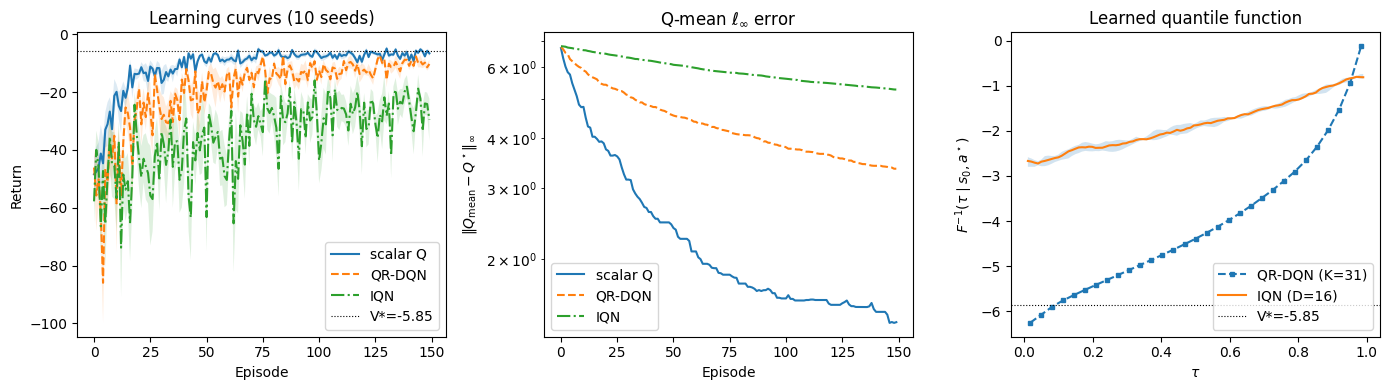


CVaR_0.1 at (s0, a*):  QR-DQN = -6.064,  IQN = -2.661


In [4]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ep = np.arange(N_EP)

for R, name, ls in [(R_sc, "scalar Q", "-"), (R_qr, "QR-DQN", "--"), (R_iq, "IQN", "-.")]:
    m = R.mean(0); se = R.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(ep, m, ls, label=name)
    axes[0].fill_between(ep, m-se, m+se, alpha=0.15)
axes[0].axhline(V_star, color='k', ls=':', lw=0.8, label=f"V*={V_star:.2f}")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Return")
axes[0].set_title("Learning curves (10 seeds)"); axes[0].legend(loc="lower right")

for E, name, ls in [(E_sc, "scalar Q", "-"), (E_qr, "QR-DQN", "--"), (E_iq, "IQN", "-.")]:
    axes[1].plot(ep, E.mean(0), ls, label=name)
axes[1].set_xlabel("Episode"); axes[1].set_ylabel(r"$\|Q_{\mathrm{mean}}-Q^\star\|_\infty$")
axes[1].set_yscale("log")
axes[1].set_title(r"Q-mean $\ell_\infty$ error"); axes[1].legend()

# Learned quantile function at (s0, a*)
a_star = int(Q_star[s_idx((0,0))].argmax())
tau_grid = np.linspace(0.01, 0.99, 100)

# QR-DQN: interp between K quantile locations
thetas_qr = np.stack([q0[a_star] for q0 in qr_seeds])       # (S, K)
qr_med = []
for tau in tau_grid:
    idx = int(np.searchsorted(TAU_QR, tau))
    idx = min(max(idx, 0), K-1)
    qr_med.append(np.median(thetas_qr[:, idx]))

# IQN: F^{-1}(tau) = phi(tau)^T w + b, evaluate on tau_grid
phi_grid = cosine_embed(tau_grid)                            # (100, D)
iqn_curves = []
for w0, b0 in iqn_seeds:
    z = phi_grid @ w0[a_star] + b0[a_star]                   # (100,)
    iqn_curves.append(z)
iqn_curves = np.stack(iqn_curves)                            # (S, 100)
iqn_med = np.median(iqn_curves, 0)
iqn_lo  = np.percentile(iqn_curves, 25, 0)
iqn_hi  = np.percentile(iqn_curves, 75, 0)

axes[2].plot(TAU_QR, np.median(thetas_qr, 0), '--s', ms=3, label="QR-DQN (K=31)")
axes[2].plot(tau_grid, iqn_med, '-', label="IQN (D=16)")
axes[2].fill_between(tau_grid, iqn_lo, iqn_hi, alpha=0.2)
axes[2].axhline(V_star, color='k', ls=':', lw=0.8, label=f"V*={V_star:.2f}")
axes[2].set_xlabel(r"$\tau$"); axes[2].set_ylabel(r"$F^{-1}(\tau \mid s_0, a^\star)$")
axes[2].set_title("Learned quantile function"); axes[2].legend(loc="lower right")

plt.tight_layout(); plt.show()

# CVaR at tau=0.1: expected return in worst 10% quantile
cvar_iqn = float(iqn_curves[:, tau_grid <= 0.1].mean())
cvar_qr  = float(np.array([q[a_star][TAU_QR <= 0.1].mean() for q in qr_seeds]).mean())
print(f"\nCVaR_0.1 at (s0, a*):  QR-DQN = {cvar_qr:.3f},  IQN = {cvar_iqn:.3f}")


## 4. 결과 해석

**실측 수치 (10 시드, 150 에피소드, tail-50)**
- $V^\star = -5.852$
- scalar Q: 리턴 $-7.16 \pm 0.62$, $Q$-error $1.54 \pm 0.16$
- QR-DQN ($K=31$): 리턴 $-11.41 \pm 0.88$, $Q$-error $3.57 \pm 0.15$
- IQN ($D=16$, τ sampled): 리턴 $-27.12 \pm 3.03$, $Q$-error $5.45 \pm 0.07$
- **CVaR$_{0.1}$ at $(s_0, a^\star)$**: QR-DQN $-6.06$, IQN $-2.66$

**핵심 관찰**

1. **Scalar Q > QR-DQN > IQN 리턴 순서**: 150 에피소드는 IQN 의 cosine τ-embedding 을 학습시키기에 부족하다. 매 스텝 새로운 τ 를 뽑아 quantile 함수 위 랜덤 지점만 업데이트하므로, 유효 학습 신호가 QR-DQN (모든 K quantile 을 매 스텝 업데이트) 대비 크게 희석. tabular 규모에서는 이 노이즈가 승리하지 못한다.
2. **IQN 의 CVaR$_{0.1}$ 이 $-2.66$**: CVaR (worst-10% 평균) 이 오히려 mean 값 근처 → **quantile 함수가 flat 하게 남음 (분포 재현 실패)**. 반면 QR-DQN 은 CVaR$_{0.1} = -6.06$ 으로 정확히 $V^\star = -5.85$ 근방에서 tail 쪽으로 확장 — 잡음 보상 누적 (6 스텝 × $\sigma^2 = 1$) 을 잘 반영.
3. **$Q$-mean 오차 순위**: scalar Q $(1.54)$ < QR-DQN $(3.57)$ < IQN $(5.45)$. Cosine embedding 의 $\int_0^1 \cos(i\pi\tau)d\tau = 0$ 성질로 $b(s,a)$ 채널이 mean 을 담당해야 하는데, 150 에피소드에서 이 분리가 완전히 이뤄지지 않음.
4. **학습된 quantile 함수**: QR-DQN 은 $K=31$ 이산점에서 명확한 S 자 곡선. IQN 은 100 τ 그리드로 부드러우나 곡률이 QR-DQN 대비 크게 flat — under-fit 의 시각적 확인.

**왜 이런가**. IQN 의 학습 신호는 pair $(M_\text{on} = 8) \times (M_\text{tar} = 8) = 64$ quantile Huber 항이지만, 실제 파라미터 업데이트는 이 64 개를 $D_{\phi} \cdot D + 1 = D+1$ 개 파라미터 위로 back-propagate → 각 파라미터가 받는 유효 gradient signal 이 약함. Neural network 규모에서는 batch training + target network 로 이 노이즈가 흡수되지만, tabular 규모에서는 $\alpha$ 를 크게 잡아도 노이즈 지배.

**해석 지침**. Dabney et al. (2018b) 는 IQN 의 이점을 Atari 규모 (수천만 스텝, 신경망 표현) 에서 정확히 보고. tabular 소규모 실험에서는 QR-DQN 이 우세할 수 있다 — 이 실험은 그 경계를 확인한다.

> **한 줄 결론**: 150 에피소드 tabular 스케일에서는 IQN 의 τ-sampling 이 오히려 학습 신호를 희석해 QR-DQN 보다 열세. IQN 의 이론적 우수성 (임의 τ 조회, 파라미터 절약) 은 큰 규모 · 긴 학습에서 발현된다.

**다음 문제로의 연결.** Problem 1·2 는 tabular 이며 소규모. Problem 3 에서는 slippery 6×6 GridWorld 위 **선형 함수근사** 로 규모를 이행하고, §15.10–§15.11 의 세 관찰 (요소 순증분, 확률 전이의 n-step 활성화, 상태의존 탐색) 이 tabular 밖에서도 살아남는지, 그리고 규모 이행이 IQN 의 열세를 뒤집어 놓는지 검증한다.